# Recalibration of Rcv1 2017_05 measurement

This is one of the receiver calibration data and coeffecients used to calibrate the lowband 1 data used in Bowman et al 2018. See MIT memo #245

We follow memo Loco memo #92, for the choices of: 
a.) Load resistance values
b.) spectra files
c.) S11 folders
d.) cterms & wterms

In [8]:
import edges_cal as ec
from edges_io import io
import matplotlib.pyplot as plt
import numpy as np
%load_ext autoreload
%autoreload 2
import h5py
from edges_cal.cal_coefficients import perform_term_sweep

In [9]:
calobs_2017_05 = ec.CalibrationObservation(path="/data5/edges/data/CalibrationObservations/Receiver01/Receiver01_25C_2017_05_01_040_to_200MHz/",  
                                         f_low = 50, f_high= 100,compile_from_def=False, run_num={'receiver_reading':2,'ambient':2}, 
                                           repeat_num={'receiver_reading':1,'ambient':1,'switching_state':1},cterms=7,wterms=7,\
                                           load_kwargs={"ignore_times_percent":20})

In [43]:
calobs_2017_05.io.run_num

{'hot_load': 1,
 'ambient': 1,
 'short': 1,
 'open': 1,
 'switching_state': 1,
 'receiver_reading': 3,
 'AntSim1': 1,
 'AntSim2': 1}

(0, 2000)

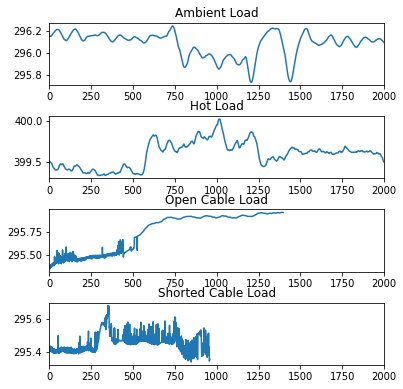

In [10]:
plt.figure(figsize=(6,8))
plt.subplots_adjust(hspace=0.5)
plt.subplot(5,1,1)
plt.plot(calobs_2017_05.ambient.spectrum.thermistor_temp)
plt.title('Ambient Load')
plt.xlim([0,2000])

plt.subplot(5,1,2)
plt.plot(calobs_2017_05.hot_load.spectrum.thermistor_temp)
plt.title('Hot Load')
plt.xlim([0,2000])

plt.subplot(5,1,3)
plt.plot(calobs_2017_05.open.spectrum.thermistor_temp)
plt.title('Open Cable Load')
plt.xlim([0,2000])

plt.subplot(5,1,4)
plt.plot(calobs_2017_05.short.spectrum.thermistor_temp)
plt.title('Shorted Cable Load')
plt.xlim([0,2000])

KeyError: "Can't open attribute (can't locate attribute: 'n_integrations')"

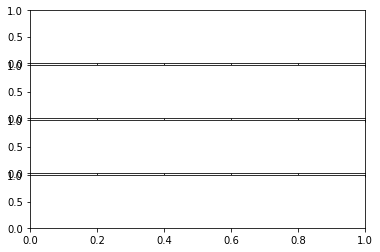

In [11]:
calobs_2017_05.plot_raw_spectra();

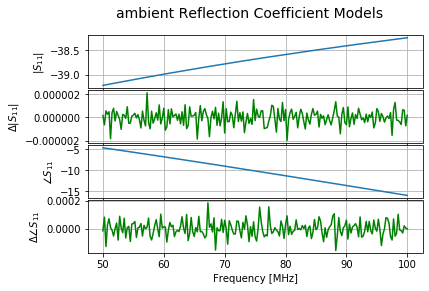

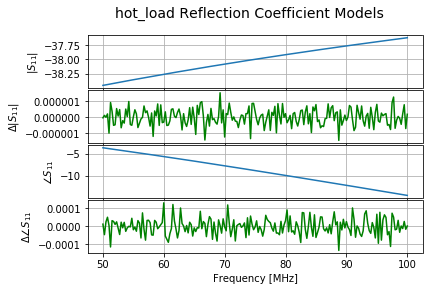

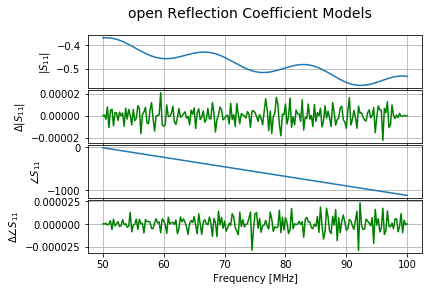

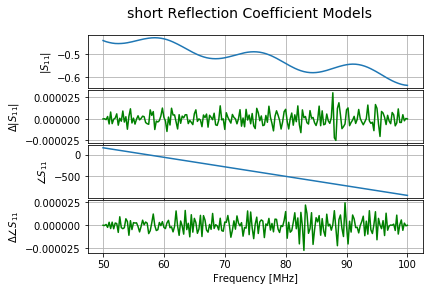

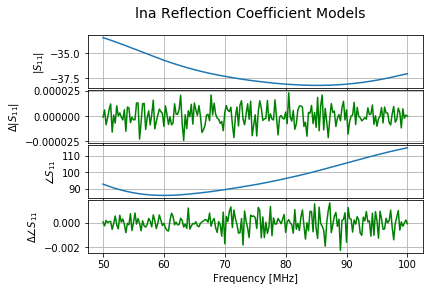

In [12]:
calobs_2017_05.plot_s11_models();

KeyError: "Can't open attribute (can't locate attribute: 'n_integrations')"

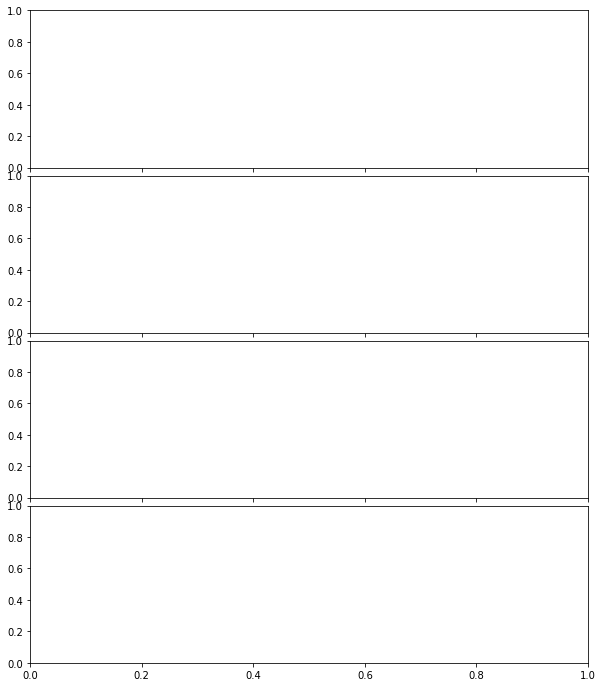

In [13]:
calobs_2017_05.plot_calibrated_temps();

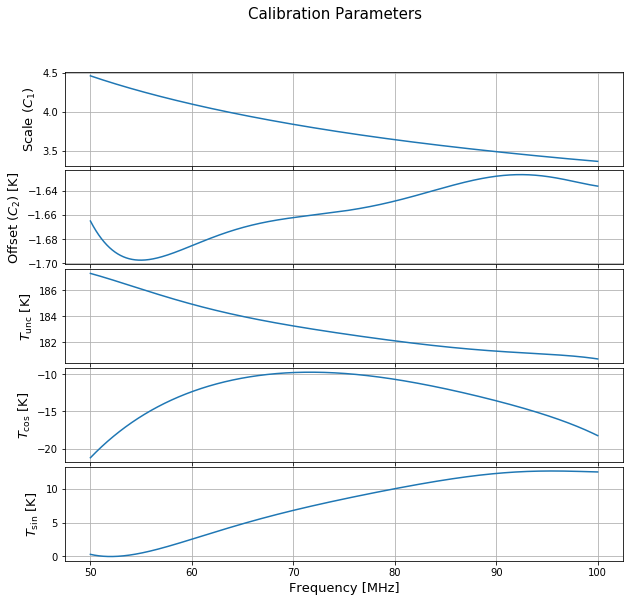

In [53]:
calobs_2017_05.plot_coefficients();

In [55]:
calobs_2017_05.write('/data4/nmahesh/edges/edges-field-levels/low1_cal_files/Rcv_2017_05.h5')

In [37]:
Antsim1 = calobs_2017_05.new_load(load_name = 'AntSim1',reflection_kwargs={"n_terms":151})

In [41]:
Antsim1.temp_ave

295.62178855292524

Text(0.5, 1.0, 'AntSim1')

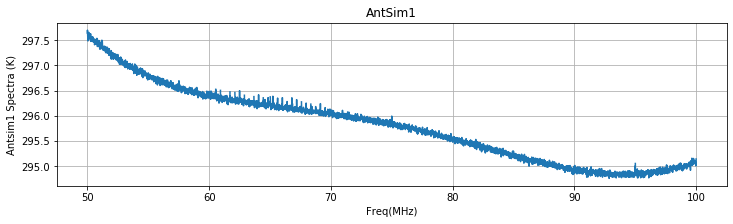

In [38]:
plt.figure(figsize=(12,3))
plt.plot(Antsim1.freq.freq,Antsim1.averaged_spectrum)
plt.grid()
plt.ylabel('Antsim1 Spectra (K)')
plt.xlabel('Freq(MHz)')
plt.title('AntSim1')

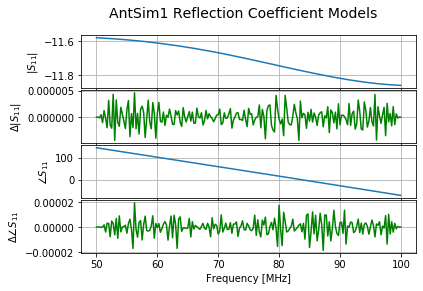

In [39]:
Antsim1.reflections.plot_residuals();

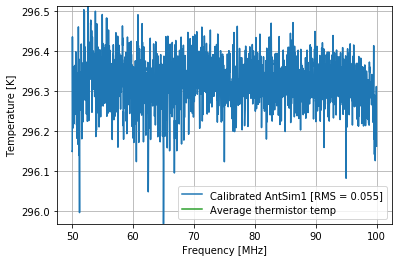

In [40]:
calobs_2017_05.plot_calibrated_temp(Antsim1);

In [8]:
Antsim2 = calobs_2017_05.new_load(load_name = 'AntSim2',run_num=1)

Text(0.5, 1.0, 'AntSim2')

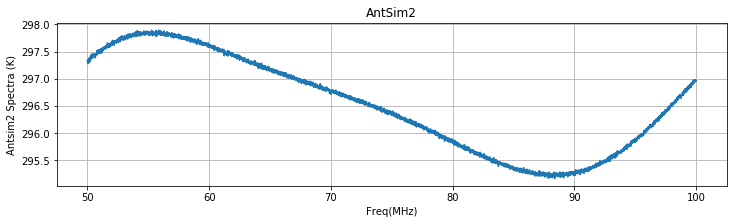

In [9]:
plt.figure(figsize=(12,3))
plt.plot(Antsim2.freq.freq,Antsim2.averaged_spectrum)
plt.grid()
plt.ylabel('Antsim2 Spectra (K)')
plt.xlabel('Freq(MHz)')
plt.title('AntSim2')

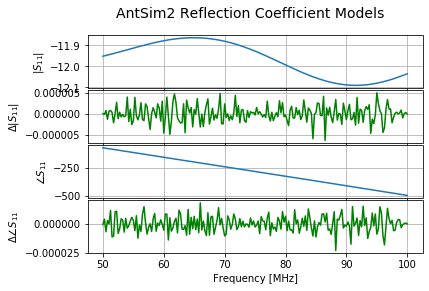

In [64]:
Antsim2.reflections.plot_residuals();

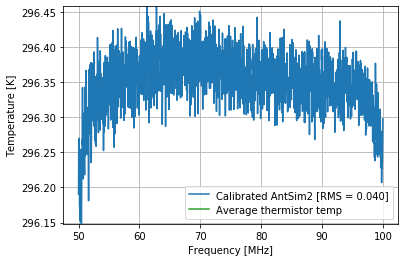

In [65]:
calobs_2017_05.plot_calibrated_temp(Antsim2);

In [42]:
Antsim2.temp_ave

295.6231975199519